<a href="https://colab.research.google.com/github/AND-SHAL-0813/vehicle-object-counter-yolov8/blob/main/vehicle_object_counter_yolov8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Install YOLOv8 framework and vision tools
!pip install ultralytics opencv-python pandas matplotlib
print("Libraries installed successfully!")

In [ ]:
import urllib.request
import os

# Create workspace folders
os.makedirs("inputs", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

# Download sample traffic image
opener = urllib.request.build_opener()
opener.addheaders = [('User-Agent', 'Mozilla/5.0')]
urllib.request.install_opener(opener)

image_url = "https://raw.githubusercontent.com/ultralytics/yolov5/master/data/images/bus.jpg"
urllib.request.urlretrieve(image_url, "inputs/sample_traffic.jpg")

print("Folders created and sample image saved to inputs/sample_traffic.jpg")

In [ ]:
# Interactive input box to enter expected vehicle count
expected_count = int(input("Enter the expected number of vehicles/objects in the image: "))
print(f"Recorded Expected Count: {expected_count}")

=== 1. ORIGINAL CAPTURED IMAGE (EXPECTED VEHICLES: 3) ===


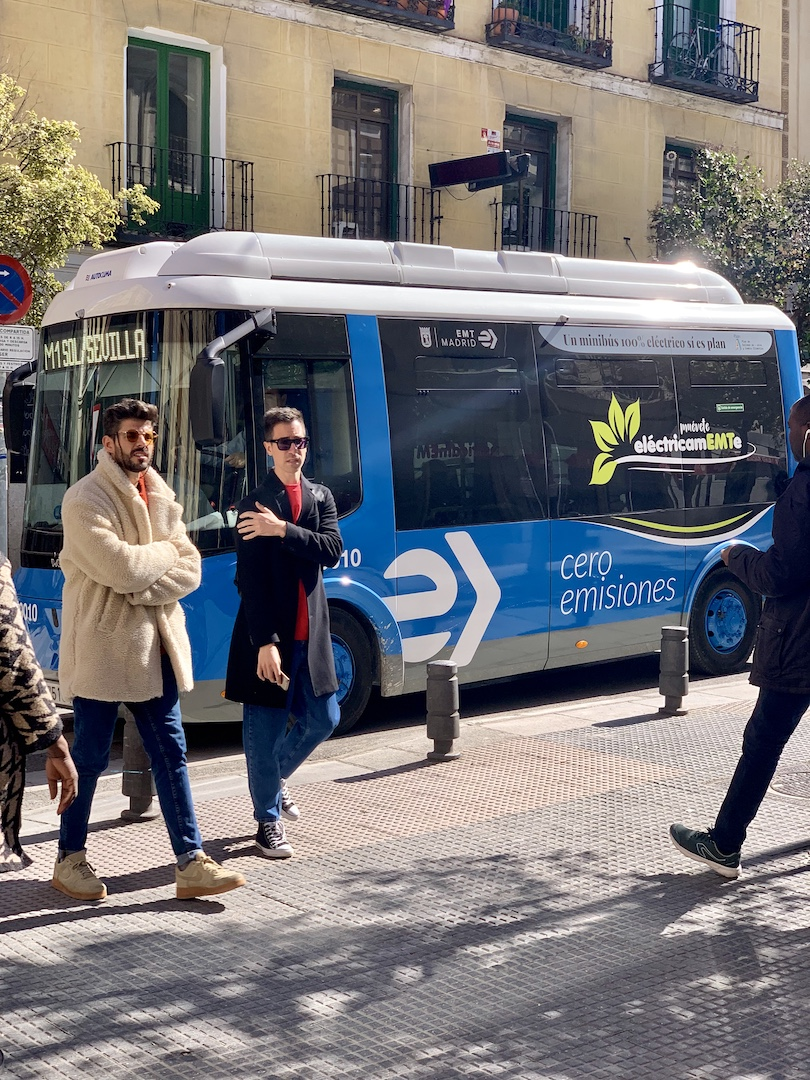

In [15]:
import cv2
from google.colab.patches import cv2_imshow

# Load and display original input image
original_image = cv2.imread("inputs/sample_traffic.jpg")

print(f"=== 1. ORIGINAL CAPTURED IMAGE (EXPECTED VEHICLES: {expected_count}) ===")
cv2_imshow(original_image)

=== 🚀 AI VISION DETECTION HUD RENDER ===


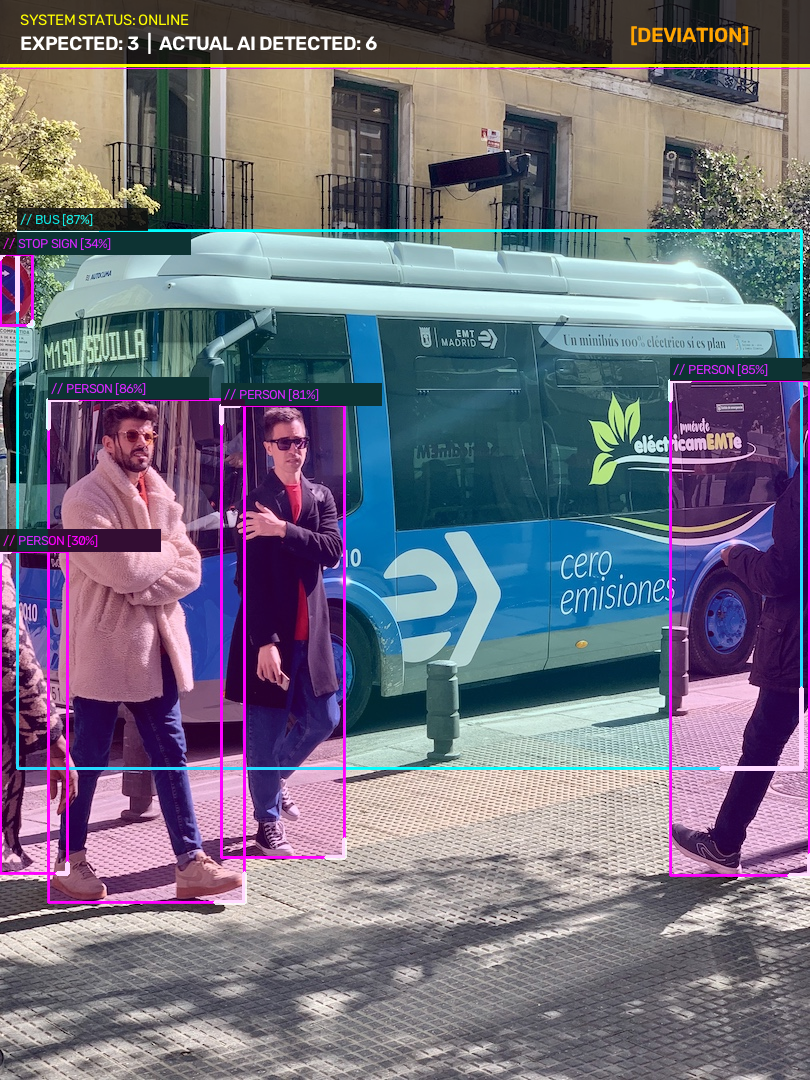


Saved HUD image to 'outputs/annotated_traffic.jpg' and CSV logs to 'outputs/vehicle_counts.csv'!


In [14]:
import cv2
import pandas as pd
import numpy as np
from datetime import datetime
from ultralytics import YOLO
from google.colab.patches import cv2_imshow

# 1. Load Model
model = YOLO('yolov8n.pt')

image_path = "inputs/sample_traffic.jpg"
image = cv2.imread(image_path)
h, w, _ = image.shape

# Run Object Detection
results = model(image_path, verbose=False)[0]

actual_count = 0
class_counts = {}

# Create semi-transparent overlay canvas
overlay = image.copy()

# 2. Draw Futuristic Bounding Boxes
for box in results.boxes:
    actual_count += 1
    cls_id = int(box.cls[0])
    class_name = model.names[cls_id]
    class_counts[class_name] = class_counts.get(class_name, 0) + 1

    x1, y1, x2, y2 = map(int, box.xyxy[0])
    conf = float(box.conf[0])

    # Futuristic Neon Colors (BGR: Electric Cyan & Neon Magenta)
    box_color = (255, 255, 0) if class_name in ['car', 'bus', 'truck', 'motorcycle'] else (255, 0, 255)

    # Draw Semi-Transparent Box Fill
    cv2.rectangle(overlay, (x1, y1), (x2, y2), box_color, -1)

    # Draw Main Bounding Box
    cv2.rectangle(image, (x1, y1), (x2, y2), box_color, 2)

    # Draw High-Tech Corner Crosshairs
    length = int(min(x2-x1, y2-y1) * 0.15)
    cv2.line(image, (x1, y1), (x1 + length, y1), (255, 255, 255), 3)
    cv2.line(image, (x1, y1), (x1, y1 + length), (255, 255, 255), 3)
    cv2.line(image, (x2, y2), (x2 - length, y2), (255, 255, 255), 3)
    cv2.line(image, (x2, y2), (x2, y2 - length), (255, 255, 255), 3)

    # Draw Futuristic Tag Header
    label = f" // {class_name.upper()} [{int(conf*100)}%]"
    cv2.rectangle(image, (x1, y1 - 22), (x1 + len(label)*10, y1), (15, 15, 15), -1)
    cv2.putText(image, label, (x1, y1 - 6), cv2.FONT_HERSHEY_SIMPLEX, 0.45, box_color, 1, cv2.LINE_AA)

# Blend fill layer for translucent target highlighting
alpha = 0.15
image = cv2.addWeighted(overlay, alpha, image, 1 - alpha, 0)

# 3. Draw Dark Glass HUD Header Banner
hud_bg = image.copy()
cv2.rectangle(hud_bg, (0, 0), (w, 65), (10, 10, 15), -1)
image = cv2.addWeighted(hud_bg, 0.75, image, 0.25, 0)

# HUD Border Accent Lines
cv2.line(image, (0, 65), (w, 65), (0, 255, 255), 2)
cv2.line(image, (0, 68), (w, 68), (255, 0, 255), 1)

# Status Badge Logic (GREEN if match, RED/AMBER if deviation)
status_color = (0, 255, 0) if actual_count == expected_count else (0, 165, 255)
status_text = "MATCHED" if actual_count == expected_count else "DEVIATION"

# Render HUD Text Metrics
cv2.putText(image, "SYSTEM STATUS: ONLINE", (20, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 1, cv2.LINE_AA)
cv2.putText(image, f"EXPECTED: {expected_count}  |  ACTUAL AI DETECTED: {actual_count}", (20, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255, 255, 255), 2, cv2.LINE_AA)
cv2.putText(image, f"[{status_text}]", (w - 180, 42), cv2.FONT_HERSHEY_SIMPLEX, 0.7, status_color, 2, cv2.LINE_AA)

# Display Aesthetic Render in Colab
print("=== 🚀 AI VISION DETECTION HUD RENDER ===")
cv2_imshow(image)

# 4. Export Clean Output Data
cv2.imwrite("outputs/annotated_traffic.jpg", image)

timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
summary_data = [{
    "Expected_Count": expected_count,
    "Actual_Detected_Count": actual_count,
    "Status": status_text,
    "Category": k,
    "Count": v,
    "Timestamp": timestamp
} for k, v in class_counts.items()]

df = pd.DataFrame(summary_data)
df.to_csv("outputs/vehicle_counts.csv", index=False)

print("\nSaved HUD image to 'outputs/annotated_traffic.jpg' and CSV logs to 'outputs/vehicle_counts.csv'!")